# **SINGLE CELL LIVE ANALYSIS FOR DIET PAPER**

This notebook contains all of the analyses for the diet paper for live single cell
### Author: Holly Vose
### Updated: 4/21/26

In [1]:
# STEP 1: Imports
import re
import os
import pprint
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gprofiler
import gseapy as gp
from gseapy import Biomart
import harmonypy as hm

warnings.filterwarnings('ignore')
sns.set_style("ticks")
sns.set_theme(style="white", context="paper")

In [3]:
# STEP 2: Load Data
adata_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260423_live_recluster.h5ad")

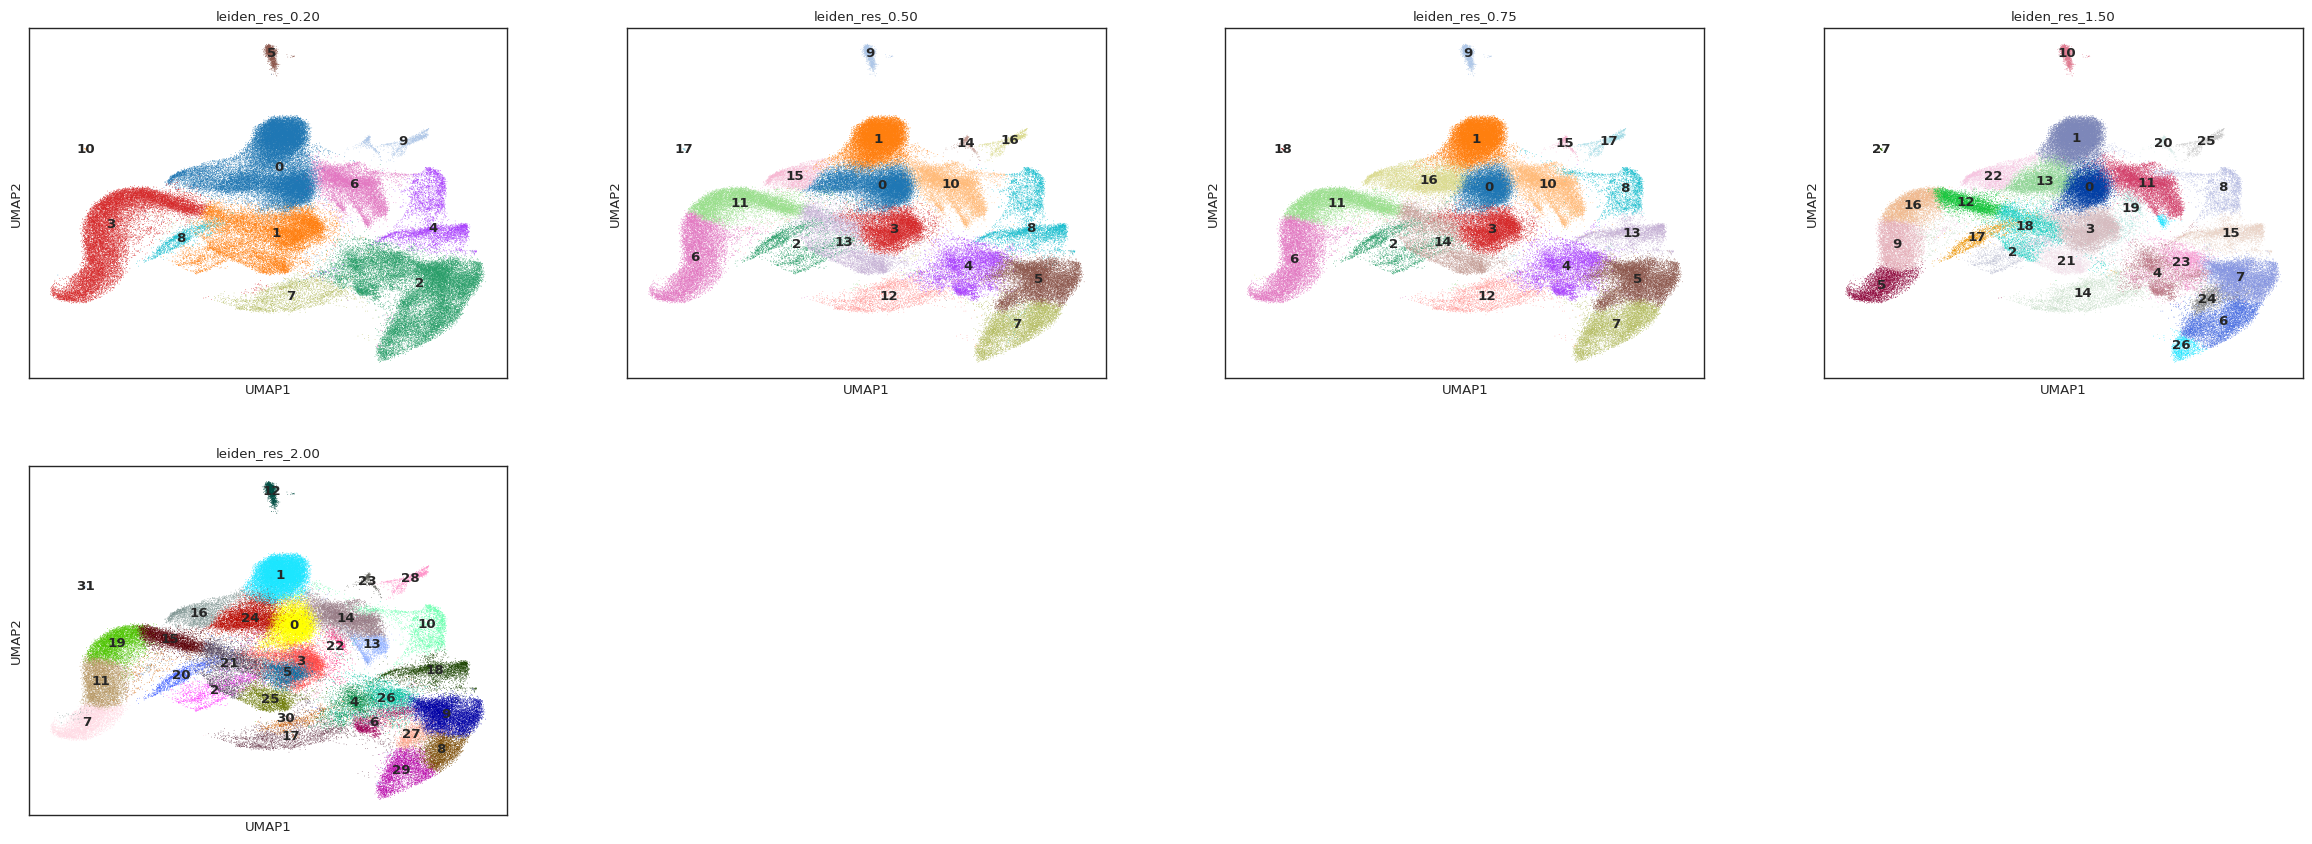

In [4]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75, 1.5, 2]:
    sc.tl.leiden(adata_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.50", "leiden_res_2.00"],
    legend_loc="on data",
) 

In [5]:
#STEP 4: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E52A3",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#6D5698",
                  "#E3BD33",
                  "#C67FAE",
                  "#A6BE47",
                  "#BAA5FF",
                  "#FDD5A1",
                  "#09094A",
                  ]

extra_cluster_colors = ["#6D5698",
                        "#98DDDF",
                        "#A00239",
                        "#009499",
                       ]

extra_extra_cluster_colors = [
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#B623CC",
                  "#D7E8BC",
                  "#BAA5FF",
]

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

In [ ]:
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "infected", "group"] = "5DPI"
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "uninfected", "group"] = "Mock"

## **INITIAL DEFINITIONS**

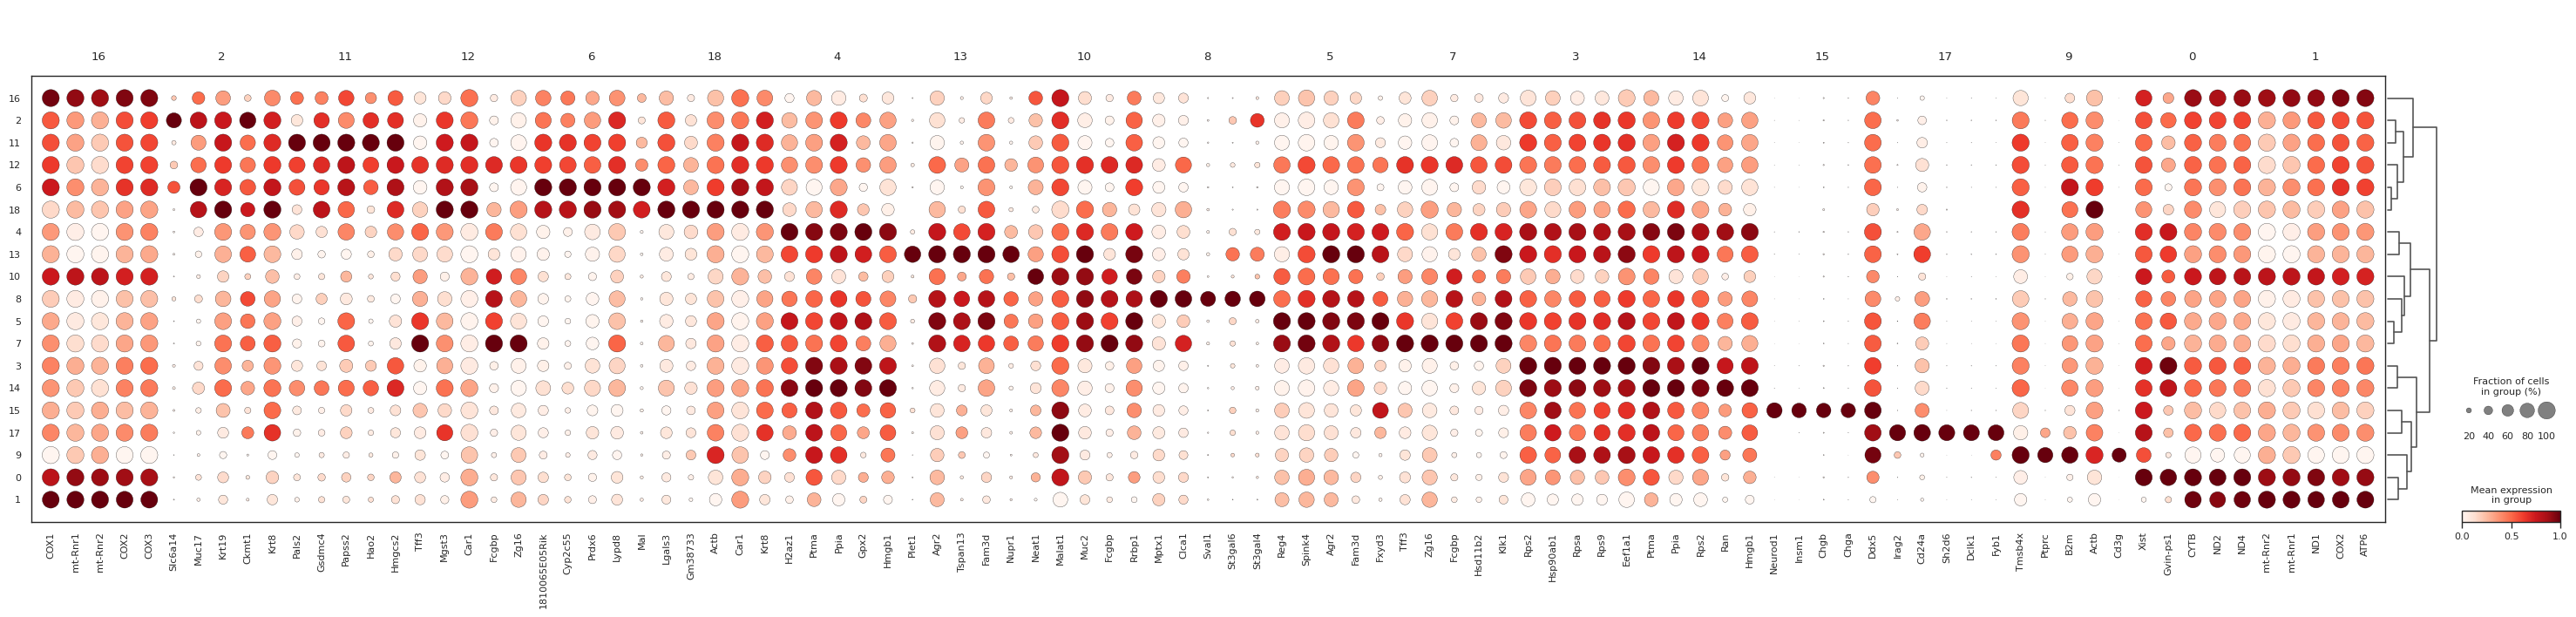

In [6]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata_filtered, groupby="leiden_res_0.75", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="leiden_res_0.75", standard_scale="var", n_genes=5,save="big_1_dotplot.png"
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

#sc.pl.umap(adata_filtered,color="group",palette=cluster_colors,mask_obs=(adata_filtered.obs["group"]=="Mock"))
#sc.pl.umap(adata_filtered,color="group",palette=cluster_colors,mask_obs=(adata_filtered.obs["group"]=="5DPI"))
sc.pl.umap(adata_filtered,color="Sval1",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="5DPI"))
sc.pl.umap(adata_filtered,color="Sval1",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="Mock"))
sc.pl.umap(adata_filtered,color="Mki67",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Lgr5",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Hes1",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Muc17",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Spdef",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Hes1",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="5DPI"))
sc.pl.umap(adata_filtered,color="Hes1",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="Mock"))
sc.pl.umap(adata_filtered,color="Gsdmc4",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="5DPI"))
sc.pl.umap(adata_filtered,color="Gsdmc4",cmap=ifitm_cmap,mask_obs=(adata_filtered.obs["group"]=="Mock"))
sc.pl.umap(adata_filtered,color="Gfi1",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="Dll1",cmap=ifitm_cmap)
sc.pl.umap(adata_filtered,color="leiden_res_1.50",palette=cluster_colors,legend_loc="on data")

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

annotation = {
    "0": "",
    "1": "",
    "2": "Absorptive Colonocytes", 
    "3": "Absorptive Colonocytes", 
    "4": "Absorptive Colonocytes", 
    "5": "Deep-crypt Goblet Cells",
    "6": "Absorptive Colonocytes",
    "7": "Goblet Cells",
    "8": "Aging Goblet Cells",
    "9": "",
    "10": "Goblet Cells",
    "11": "Transit Amplifying Cells",
    "12": "Transit Amplifying Cells",
    "13": "Stem Cells",
    "14": "Absorptive Colonocytes",
    "15": "Dying Cells", 
    "16": "",
    "17": "Goblet Cells (Mature)",
    "18": "Goblet Cell Progenitor",
}

adata_filtered.obs['cluster_cell_type'] = adata_filtered.obs["leiden_res_0.50"].map(annotation).astype('category')

In [7]:
#GENERATE COPIES FOR EACH INDIVIDUAL UMAP
#cd3 = adata_diet_filtered[:,'Spink4'].X

epcam_subset = adata_filtered[
    (adata_filtered[:,'Epcam'].X.toarray() > 0.25) &
    (adata_filtered[:, 'Ptprc'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd79a'].X.toarray() < 0.01) &
    (adata_filtered[:, 'Cd19'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3e'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3d'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3g'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd247'].X.toarray() < 0.01)
].copy()
# if isinstance(cd3, (np.ndarray, list)):
#     #for dense arrays or lists
#     mask = muc.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     mask = (cd3.toarray().flatten() > 0)

# adata_subset_view = adata_diet_filtered[~mask, :]

# adata_cd3_diet = adata_subset_view.copy()
#adata_cd3_diet_filteredf = adata_cd3_diet_filtered[adata_cd3_diet_filtered.obs['leiden_res_0.20'].isin(['0','1','3'])].copy()
print(epcam_subset)

AnnData object with n_obs × n_vars = 105674 × 25606
    obs: 'sample', 'i_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_mhvy', 'log1p_total_counts_mhvy', 'pct_counts_mhvy', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'group', 'leiden_res_0.20', 'leiden_res_0.50', 'leiden_res_0.75', 'leiden_res_1.50', 'leiden_res_2.00'
    var: 'mt', 'mhvy', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'i_type_colors', 'leiden', 'leiden_res_0.20', 'leiden_res_0.20_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'leiden_res

In [8]:
sc.pp.pca(epcam_subset)

In [9]:
# Get PCs from the AnnData object
pcs = epcam_subset.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, epcam_subset.obs, "i_type")

print("finished harmony")

# Store corrected PCs back in the AnnData object
epcam_subset.obsm['X_pca_harmony'] = harmony_out.Z_corr


(105674, 50)


2026-05-18 13:30:06,621 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-18 13:30:06,622 - harmonypy - INFO -   Parameters:
2026-05-18 13:30:06,622 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-18 13:30:06,622 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-18 13:30:06,623 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-18 13:30:06,623 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-18 13:30:06,623 - harmonypy - INFO -     nclust: 100
2026-05-18 13:30:06,624 - harmonypy - INFO -     block_size: 0.05
2026-05-18 13:30:06,624 - harmonypy - INFO -     lamb: [1. 1.]
2026-05-18 13:30:06,625 - harmonypy - INFO -     theta: [2. 2.]
2026-05-18 13:30:06,625 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-18 13:30:06,625 - harmonypy - INFO -     verbose: True
2026-05-18 13:30:06,626 - harmonypy - INFO -     random_state: 0
2026-05-18 13:30:06,626 - harmonypy - INFO -   Data: 50 PCs × 105674 cells
2026-05-18 13:30:06,626 - harmonypy - INF

finished harmony


In [10]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(epcam_subset, use_rep='X_pca_harmony')
sc.tl.umap(epcam_subset)
sc.tl.leiden(epcam_subset)

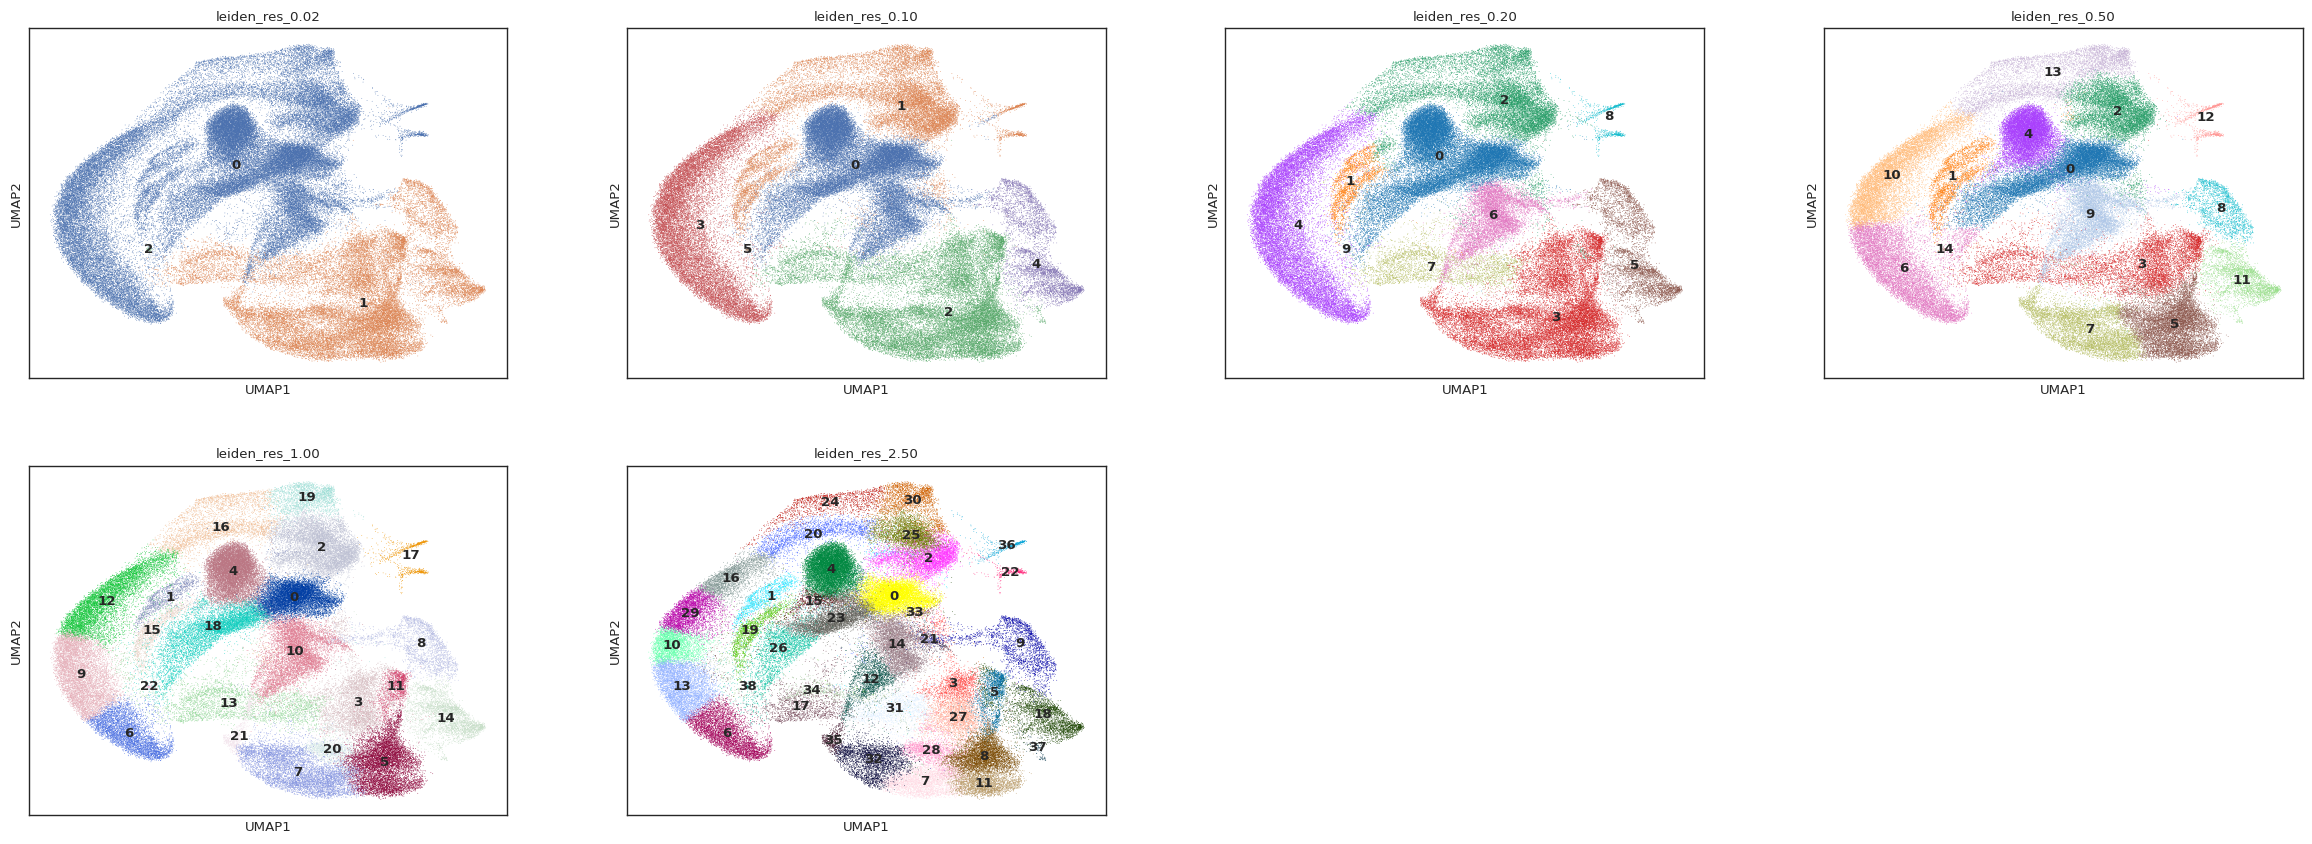

In [11]:
for res in [0.02, 0.1, 0.2, 0.5, 1.0, 2.5]:
    sc.tl.leiden(epcam_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    epcam_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_1.00","leiden_res_2.50"],
    legend_loc="on data",
)

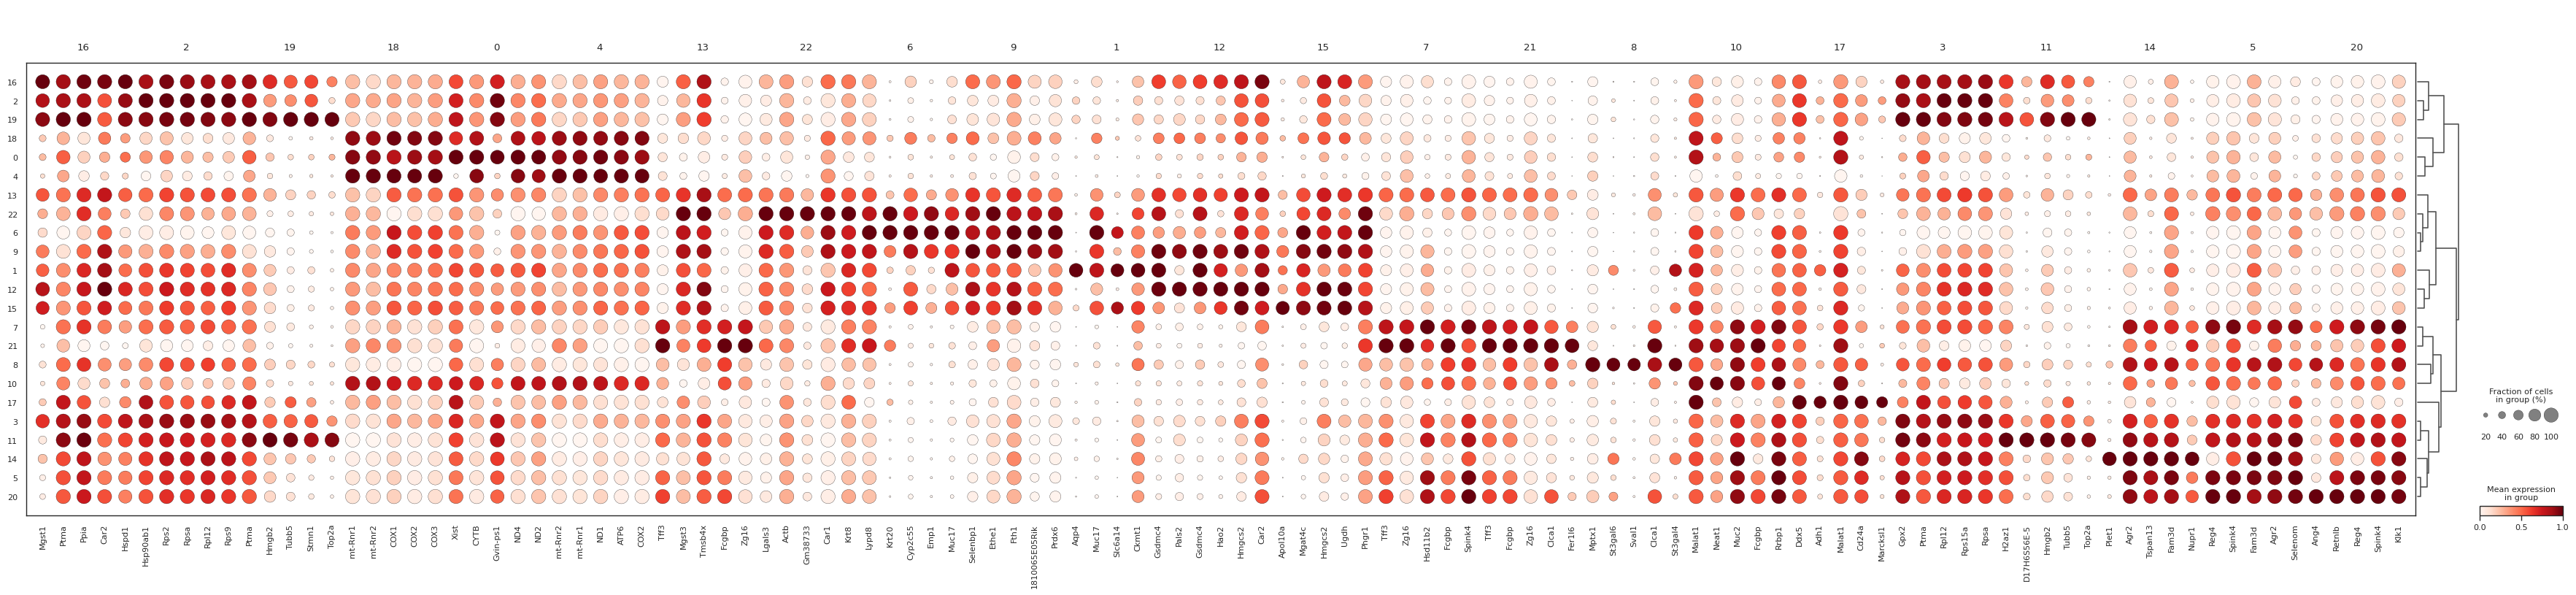

In [12]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="leiden_res_1.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="leiden_res_1.00", standard_scale="var", n_genes=5
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [14]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

e_annotation = {
    "0": "Transit Amplifying Cells",
    "1": "Absorptive Colonocytes",
    "2": "Stem Cells", 
    "3": "Deep-crypt Goblet Cells", 
    "4": "Dying Cells", 
    "5": "Transit Amplifying Cells",
    "6": "Absorptive Colonocytes",
    "7": "Goblet Cells",
    "8": "Goblet Cells",
    "9": "Mature Goblet Cells",
    "10": "Absorptive Colonocytes",
    "11": "Secretory Progenitors",
    "12": "Absorptive Progenitors",
    "13": "Absorptive Colonocytes",
    "14": "Secretory Progenitors",
    "15": "Absorptive Colonocytes",
    "16": "Absorptive Colonocytes",
    "17": "Tuft and Enteroendocrine Cells",
    "18": "Absorptive Colonocytes",
    "19": "Transit Amplifying Cells",
    "20": "Goblet Cells",
    "21": "Absorptive Colonocytes"
}

epcam_subset.obs['cluster_cell_type'] = epcam_subset.obs["leiden_res_1.00"].map(e_annotation).astype('category')

In [21]:
genes_to_gen = ['Dll1']

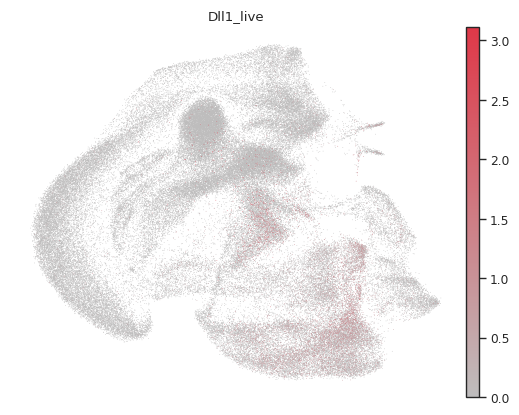

In [22]:
for gene in genes_to_gen:
    sc.pl.umap(epcam_subset, color=gene, cmap=ifitm_cmap, frameon=False, title=f"{gene}_live",save=f"/live/{gene}.svg")

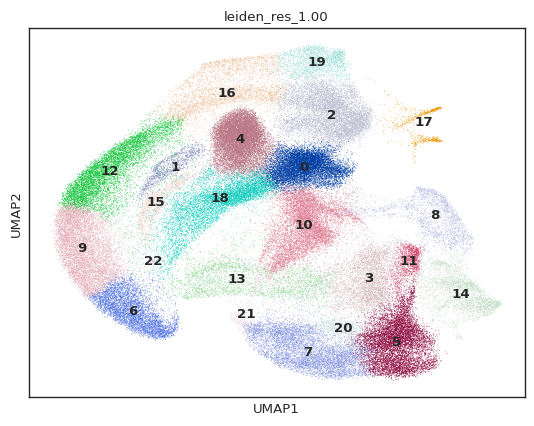

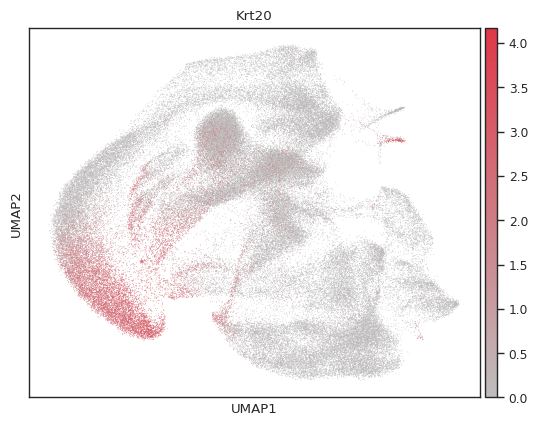

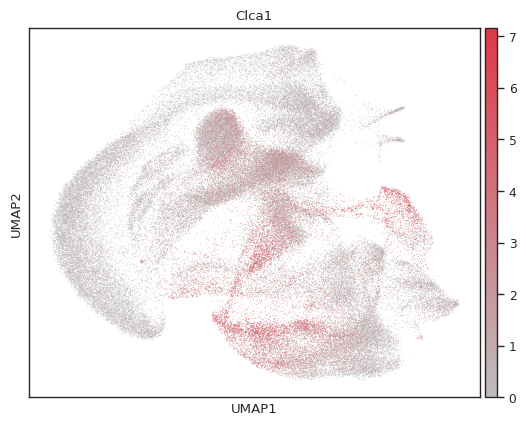

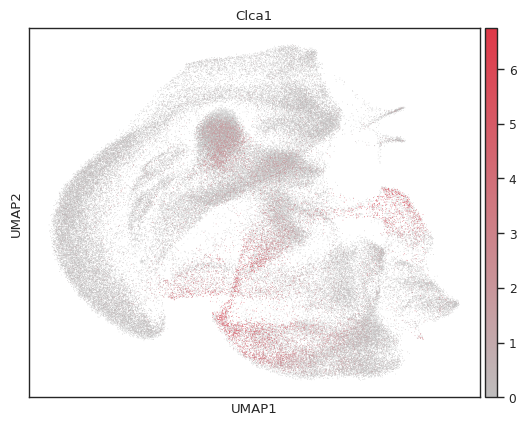

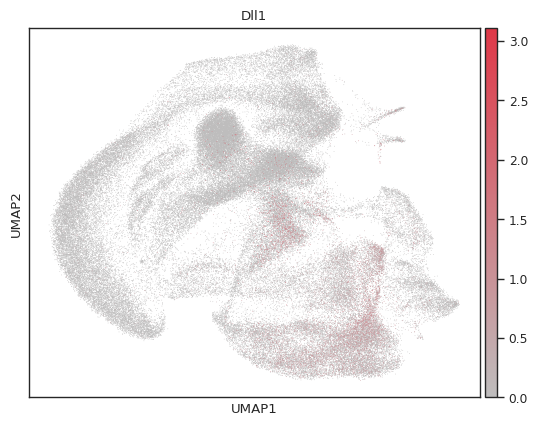

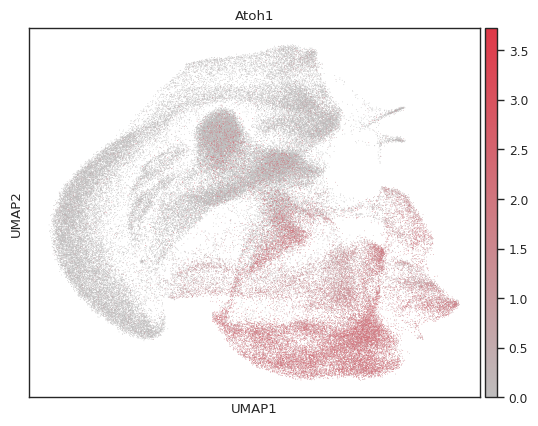

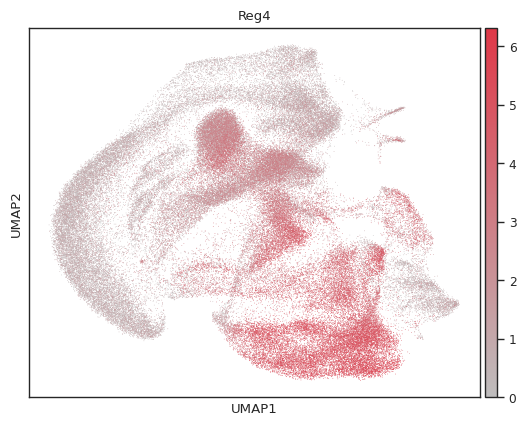

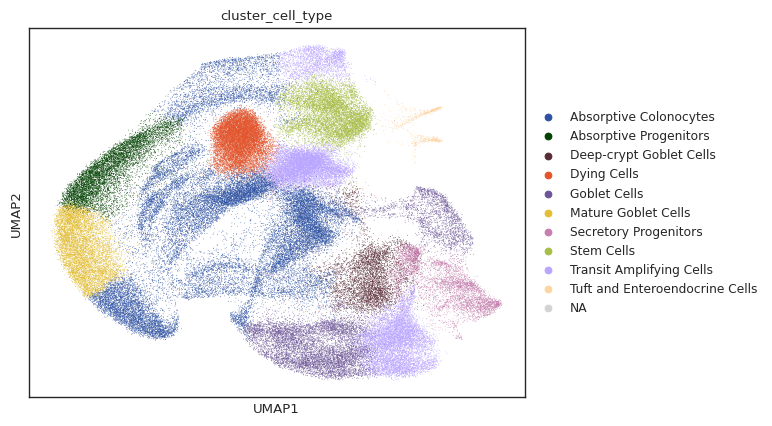

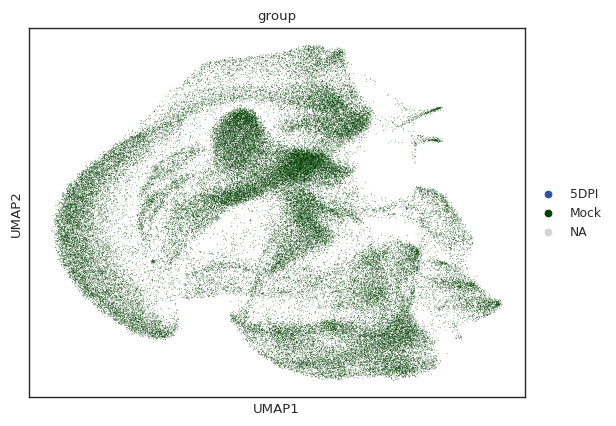

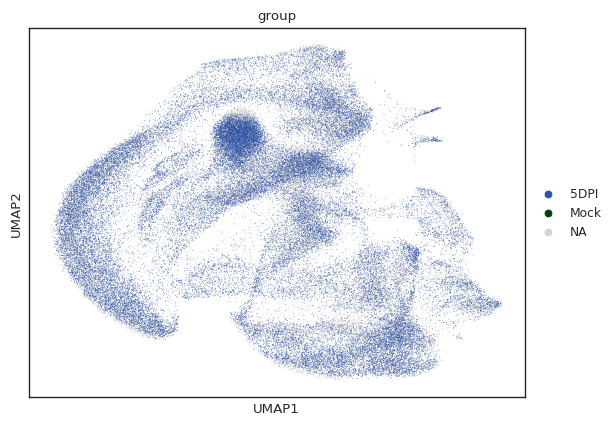

In [16]:
#sc.pl.umap(epcam_subset,color="cluster_cell_type",palette=cluster_colors,frameon=False,save="/live/full_umap.svg")
sc.pl.umap(epcam_subset,color="leiden_res_1.00",cmap=ifitm_cmap,legend_loc="on data")
sc.pl.umap(epcam_subset,color="Krt20",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Clca1",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["group"]=="Mock"))
sc.pl.umap(epcam_subset,color="Clca1",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["group"]=="5DPI"))
sc.pl.umap(epcam_subset,color="Dll1",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Atoh1",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Reg4",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="cluster_cell_type",palette=cluster_colors)
sc.pl.umap(epcam_subset,color="group",palette=cluster_colors,mask_obs=(epcam_subset.obs["group"]=="Mock"))
sc.pl.umap(epcam_subset,color="group",palette=cluster_colors,mask_obs=(epcam_subset.obs["group"]=="5DPI"))

In [51]:
#generate a DEG list of a specific cluster comparing two specific conditions
diet_clusters = epcam_subset.obs["cluster_cell_type"].cat.categories.tolist()

amp_overlap = []
nf_overlap = []
total_overlap = []

with open("live_epcam_gene_lists.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        curr_clus = epcam_subset[(epcam_subset.obs["cluster_cell_type"] == vclus)]
        sc.tl.rank_genes_groups(curr_clus, groupby="group", group="5DPI",method='wilcoxon',reference="Mock",key_added=f"live_{vclus}")
        df_curr = sc.get.rank_genes_groups_df(curr_clus, group="5DPI",key=f"live_{vclus}")

        title_fix = re.search(r"(.+) (.+)",vclus)

        if title_fix is not None:
            df_curr.to_csv(f"live_{title_fix.group(1)}_{title_fix.group(2)}.csv",index=False)
        else:
            df_curr.to_csv(f"live_{vclus}.csv",index=False)
    
        up = df_curr[(df_curr['pvals_adj'] < 0.05) & (df_curr['logfoldchanges'] > 0)]
        dw = df_curr[(df_curr['pvals_adj'] < 0.05) & (df_curr['logfoldchanges'] < 0)]
    
        # combined_up = amp_up.loc[(amp_up['names'].isin(nf_up['names']))]
        # combined_dw = amp_dw.loc[(amp_dw['names'].isin(nf_dw['names']))]
        # amp_up_only = amp_up.loc[~(amp_up['names'].isin(nf_up['names']))]
        # amp_dw_only = amp_dw.loc[~(amp_dw['names'].isin(nf_dw['names']))]
        # nf_up_only = nf_up.loc[~(nf_up['names'].isin(amp_up['names']))]
        # nf_dw_only = nf_dw.loc[~(nf_dw['names'].isin(amp_dw['names']))]

        # title = f"/publication_data/{vclus}_{}"
        f.write(f"5DPI UP (MOCK DW) FOR {vclus}:\n")
        f.write(f"{str(up['names'].tolist())}\n")
        f.write(f"5DPI DW (MOCK UP) FOR {vclus}:\n")
        f.write(f"{str(dw['names'].tolist())}\n")
        # f.write(f"AMP UP ONLY FOR {vclus}:\n")
        # f.write(f"{str(amp_up_only['names'].tolist())}\n")
        # f.write(f"AMP DW ONLY FOR {vclus}:\n")
        # f.write(f"{str(amp_dw_only['names'].tolist())}\n")
        # f.write(f"NO FIBER UP ONLY FOR {vclus}:\n")
        # f.write(f"{str(nf_up_only['names'].tolist())}\n")
        # f.write(f"NO FIBER DW ONLY FOR {vclus}:\n")
        # f.write(f"{str(nf_dw_only['names'].tolist())}\n")

    # print(f"CLUSTER {vclus}:")
    #print(f"Out of {len(sig_df_vg_mhvy_up)} total MHVY-up genes, {len(sig_df_vg_mhvy_dw)} total MHVY-down genes, {len(sig_df_vg_dhe_up)} total dHE-up genes, and {len(sig_df_vg_dhe_dw)} total dHE-down genes")
    # print(f"COMBINED UPREGULATED: {len(vg_combined_up['names'])}")
    # print(vg_combined_up['names'].tolist())
    # print(f"MHVY ONLY: {len(vg_mhvy_up_only['names'])}")
    # print(vg_mhvy_up_only['names'].tolist())
    # print(f"dHE ONLY: {len(vg_dhe_up_only['names'])}")
    # print(vg_dhe_up_only['names'].tolist())
    # combined_vals.append(len(vg_combined_up['names']))
    # mhvy_only_vals.append(len(vg_mhvy_up_only['names']))
    # dhe_only_vals.append(len(vg_dhe_up_only['names']))
    

